# 04 Logistic Regression With Basic Image Features

This is the first real supervised image-feature model. Logistic Regression is a simple linear classifier, so this notebook tests whether basic intensity, entropy, and edge-density features from cropped SEM image content can improve on the majority-class dummy baseline.

## 1. Project setup

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

## 2. Imports

In [2]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mse446_matplotlib")

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay

from src.extract_basic_features import BASIC_FEATURE_COLUMNS, FEATURES_CSV
from src.train_logistic_regression import (
    CLASS_LABELS,
    CONFUSION_MATRIX_FIGURE,
    SCORES_CSV,
    choose_group_split,
    evaluate_predictions,
    load_features,
    make_model,
    print_dummy_comparison,
    save_confusion_matrix_figure,
)

## 3. Paths and configuration

In [3]:
print(f"Basic features CSV: {FEATURES_CSV}")
print(f"Scores CSV: {SCORES_CSV}")
print(f"Confusion matrix figure: {CONFUSION_MATRIX_FIGURE}")

Basic features CSV: /home/jp/MSE446_Nanoparticle_Ordering/data/features_basic.csv
Scores CSV: /home/jp/MSE446_Nanoparticle_Ordering/results/model_scores_logistic_basic.csv
Confusion matrix figure: /home/jp/MSE446_Nanoparticle_Ordering/results/figures/confusion_matrix_logistic_basic.png


## 4. Load metadata

In [4]:
features = load_features(FEATURES_CSV)
features.head()

,filename,label,sample,area,area_group,kv,mm,mag,param_group,mean_intensity,...,min_intensity,max_intensity,p10_intensity,p25_intensity,p50_intensity,p75_intensity,p90_intensity,entropy,bright_pixel_ratio,edge_density
0,kv-10p0kV__mm-11p3mm__label-ordered__sample-S1...,ordered,S1,no_area,S1__no_area,10p0kV,11p3mm,100k,10p0kV__11p3mm__100k,0.354890,...,0.160784,0.964706,0.266667,0.298039,0.345098,0.396078,0.447059,6.260059,0.099014,0.161224
1,kv-10p0kV__mm-11p3mm__label-ordered__sample-S1...,ordered,S1,no_area,S1__no_area,10p0kV,11p3mm,100k,10p0kV__11p3mm__100k,0.414923,...,0.094118,1.000000,0.329412,0.376471,0.407843,0.447059,0.486275,6.191408,0.098190,0.113770
2,kv-10p0kV__mm-11p3mm__label-ordered__sample-S1...,ordered,S1,no_area,S1__no_area,10p0kV,11p3mm,100k,10p0kV__11p3mm__100k,0.311404,...,0.141176,1.000000,0.247059,0.266667,0.286275,0.317647,0.423529,5.814114,0.097717,0.160583
3,kv-10p0kV__mm-11p3mm__label-ordered__sample-S1...,ordered,S1,no_area,S1__no_area,10p0kV,11p3mm,100k,10p0kV__11p3mm__100k,0.326249,...,0.113725,1.000000,0.235294,0.266667,0.313726,0.368627,0.419608,6.261398,0.098694,0.164108
4,kv-10p0kV__mm-11p3mm__label-ordered__sample-S1...,ordered,S1,no_area,S1__no_area,10p0kV,11p3mm,100k,10p0kV__11p3mm__100k,0.260067,...,0.000000,1.000000,0.117647,0.176471,0.235294,0.294118,0.415686,6.846660,0.099258,0.171616


## 5. Sanity checks

In [5]:
print(f"Rows: {len(features)}")
print("Label counts:")
print(features["label"].value_counts().sort_index())
print(f"Image feature columns: {len(BASIC_FEATURE_COLUMNS)}")
print(BASIC_FEATURE_COLUMNS)
assert set(BASIC_FEATURE_COLUMNS).issubset(features.columns)
assert features["area_group"].notna().all()

Rows: 1000
Label counts:
label
disordered    250
ordered       750
Name: count, dtype: int64
Image feature columns: 12
['mean_intensity', 'std_intensity', 'min_intensity', 'max_intensity', 'p10_intensity', 'p25_intensity', 'p50_intensity', 'p75_intensity', 'p90_intensity', 'entropy', 'bright_pixel_ratio', 'edge_density']


## 6. Main analysis

Only image-derived feature columns are used as predictors. Metadata columns such as label, sample, area, voltage, working distance, and magnification are used only for labels, splitting, and audit checks.

In [6]:
train_idx, test_idx, selected_seed, split_distance = choose_group_split(features)

groups = features["area_group"]
assert set(groups.iloc[train_idx]).isdisjoint(set(groups.iloc[test_idx]))

X = features[BASIC_FEATURE_COLUMNS]
y = features["label"]
X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

model = make_model()
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

scores, report, matrix = evaluate_predictions(
    y_train,
    y_test,
    y_train_pred,
    y_test_pred,
    selected_seed,
    split_distance,
)
scores

,model,train_accuracy,test_accuracy,test_balanced_accuracy,macro_precision,macro_recall,macro_f1,disordered_recall,selected_split_seed,split_distribution_distance,train_size,test_size
0,logistic_regression_basic,0.806338,0.790541,0.779279,0.734082,0.779279,0.747676,0.756757,140,0.0,852,148


## 7. Results/figures

Balanced accuracy and macro F1 matter more than raw accuracy because the dataset has many more ordered images than disordered images. A useful model should improve disordered recall compared with the dummy baseline.

Selected split seed: 140
Train label counts:
label
disordered    213
ordered       639
Name: count, dtype: int64
Test label counts:
label
disordered     37
ordered       111
Name: count, dtype: int64

Per-class precision/recall/F1:
              precision    recall  f1-score   support

  disordered       0.56      0.76      0.64        37
     ordered       0.91      0.80      0.85       111

    accuracy                           0.79       148
   macro avg       0.73      0.78      0.75       148
weighted avg       0.82      0.79      0.80       148


Dummy vs Logistic Regression:
dummy accuracy: 0.8858
dummy balanced accuracy: 0.5000
dummy macro F1: 0.4697
logistic accuracy: 0.7905
logistic balanced accuracy: 0.7793
logistic macro F1: 0.7477
logistic disordered recall: 0.7568
Saved scores to /home/jp/MSE446_Nanoparticle_Ordering/results/model_scores_logistic_basic.csv
Saved confusion matrix to /home/jp/MSE446_Nanoparticle_Ordering/results/figures/confusion_matrix_logistic_basic.png


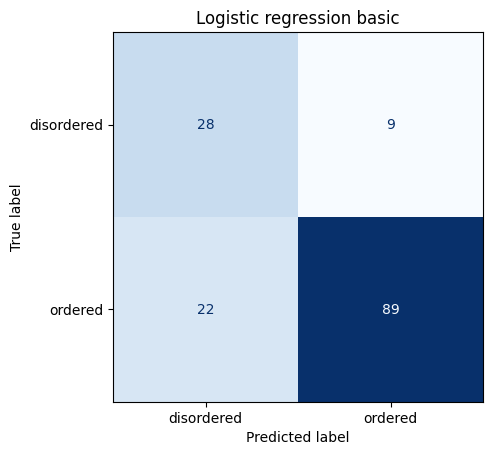

In [7]:
scores.to_csv(SCORES_CSV, index=False)
figure_path = save_confusion_matrix_figure(y_test, y_test_pred, CONFUSION_MATRIX_FIGURE)

print("Selected split seed:", selected_seed)
print("Train label counts:")
print(y_train.value_counts().sort_index())
print("Test label counts:")
print(y_test.value_counts().sort_index())
print("\nPer-class precision/recall/F1:")
print(report)
print_dummy_comparison(scores)
print(f"Saved scores to {SCORES_CSV}")
print(f"Saved confusion matrix to {figure_path}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    labels=CLASS_LABELS,
    cmap="Blues",
    colorbar=False,
)
plt.title("Logistic regression basic")
plt.show()

## 8. Notes for report

- This is the first model that uses actual image content as predictors.
- The feature set is intentionally simple and excludes HOG, graph features, and CNN representations.
- Metadata is not used as model input; it is retained only for splitting and interpretation.